# AI Travel Analyst

## Project Overview

This project analyzes a flight pricing dataset to understand the factors associated with flight prices and to identify useful patterns for travelers.

The analysis focuses on data cleaning, exploratory analysis, meaningful visualizations, and data-driven recommendations.

## Objectives

* Clean and preprocess the flight pricing data.
* Analyze patterns in flight prices.
* Identify major factors associated with flight prices.
* Provide useful recommendations based on the analysis.


In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [201]:
df = pd.read_csv("flight_pricing_dataset - flight_pricing_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 100000
Columns: 18


In [202]:
df.head()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.8,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,7:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Flight_ID              100000 non-null  str  
 1   Airline                95120 non-null   str  
 2   Source                 95085 non-null   str  
 3   Destination            95119 non-null   str  
 4   Departure_Date         95073 non-null   str  
 5   Departure_Time         95132 non-null   str  
 6   Arrival_Time           95211 non-null   str  
 7   Duration               94958 non-null   str  
 8   Total_Stops            95095 non-null   str  
 9   Distance_km            95077 non-null   str  
 10  Travel_Class           95137 non-null   str  
 11  Days_Before_Departure  95216 non-null   str  
 12  Season                 95224 non-null   str  
 13  Weekday                95280 non-null   str  
 14  Aircraft_Type          95148 non-null   str  
 15  Booking_Channel        95038 

In [204]:


def duration_to_minutes(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    # Format: "3h 11m", "1h 28m", etc.
    if "h" in value:
        hours = re.search(r"(\d+(?:\.\d+)?)h", value)
        minutes = re.search(r"(\d+(?:\.\d+)?)m", value)

        h = float(hours.group(1)) if hours else 0
        m = float(minutes.group(1)) if minutes else 0

        return h * 60 + m

    # Format: "177 min"
    if "min" in value:
        return float(value.replace("min", "").strip())

    # Decimal values such as 1.67, 13.93
    return float(value) * 60


df["Duration_minutes"] = df["Duration"].apply(duration_to_minutes)

print(df[["Duration", "Duration_minutes"]].head(10))


  Duration  Duration_minutes
0     1.67             100.2
1   0h 45m              45.0
2     14.8             888.0
3   3h 11m             191.0
4    13.93             835.8
5  16h 47m            1007.0
6   1h 28m              88.0
7   5h 27m             327.0
8  17h 04m            1024.0
9   3h 20m             200.0


In [205]:
def stops_to_number(value):
    if pd.isna(value):
        return None

    value = str(value).strip().lower()

    if value == "non-stop":
        return 0

    if "stop" in value:
        return int(value.split()[0])

    return int(float(value))


df["Total_Stops_clean"] = df["Total_Stops"].apply(stops_to_number)

print(df[["Total_Stops", "Total_Stops_clean"]].head(10))


  Total_Stops  Total_Stops_clean
0           0                0.0
1    non-stop                0.0
2      1 stop                1.0
3           1                1.0
4    non-stop                0.0
5           1                1.0
6           0                0.0
7         NaN                NaN
8           1                1.0
9           0                0.0


In [206]:
numeric_columns = [
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Price"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_columns].dtypes)

Distance_km              float64
Days_Before_Departure    float64
Passenger_Count          float64
Price                    float64
dtype: object


In [207]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 98039


In [208]:
df = df.dropna(subset=["Price"])

print("Rows after removing missing prices:", len(df))

Rows after removing missing prices: 90258


In [209]:
numeric_columns = [
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Duration_minutes",
    "Total_Stops_clean"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [210]:
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Weekday",
    "Aircraft_Type",
    "Booking_Channel"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [211]:
df = df.drop(columns=[
    "Departure_Date",
    "Departure_Time",
    "Arrival_Time",
    "Duration",
    "Total_Stops"
])

In [212]:
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
Flight_ID                0
Airline                  0
Source                   0
Destination              0
Distance_km              0
Travel_Class             0
Days_Before_Departure    0
Season                   0
Weekday                  0
Aircraft_Type            0
Booking_Channel          0
Passenger_Count          0
Price                    0
Duration_minutes         0
Total_Stops_clean        0
dtype: int64


In [213]:
print("Final dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape: (90258, 15)
Duplicate rows: 0


In [214]:
df["Price"].describe()

count     90258.000000
mean      73026.488942
std       77758.536856
min         152.130000
25%       13317.805000
50%       49159.030000
75%      113713.815000
max      999306.030000
Name: Price, dtype: float64

In [215]:
print("Average price:", df["Price"].mean())
print("Median price:", df["Price"].median())
print("Minimum price:", df["Price"].min())
print("Maximum price:", df["Price"].max())

Average price: 73026.48894214364
Median price: 49159.03
Minimum price: 152.13
Maximum price: 999306.03


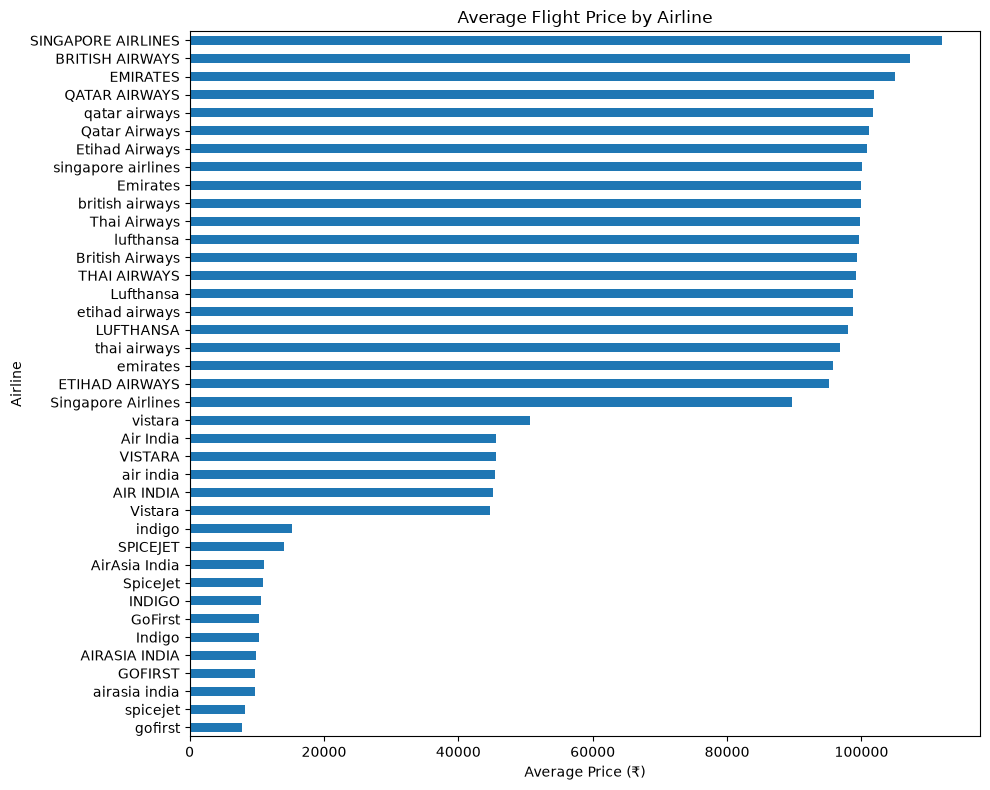

In [216]:

airline_prices = (
    df.groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))
airline_prices.plot(kind="barh")

plt.title("Average Flight Price by Airline")
plt.xlabel("Average Price (₹)")
plt.ylabel("Airline")

plt.tight_layout()
plt.show()

### Insight

Average flight prices vary considerably across airlines in this dataset. Some airlines have substantially higher average prices than others.

However, this difference should not be interpreted as the airline itself causing the higher price, because factors such as travel class, route, distance, and number of stops may also differ between airlines.


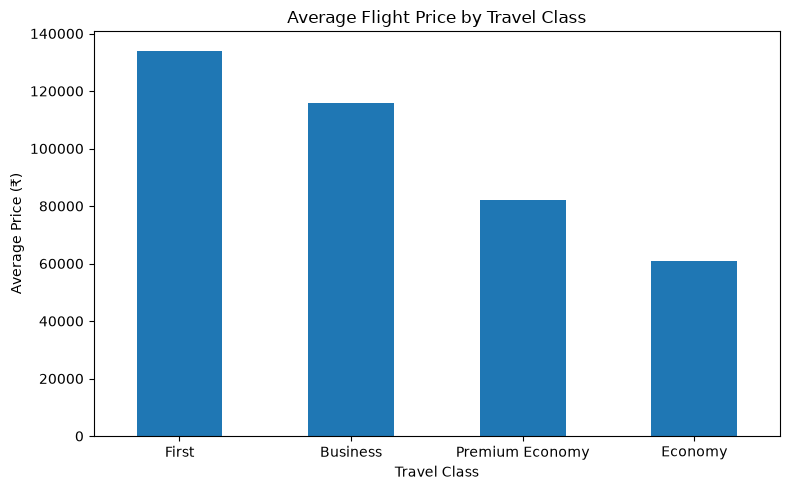

In [217]:
class_prices = (
    df.groupby("Travel_Class")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
class_prices.plot(kind="bar")

plt.title("Average Flight Price by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Travel class shows a strong association with flight price in this dataset. First class has the highest average price, followed by Business, Premium Economy, and Economy.

This suggests that travel class is one of the major factors associated with differences in flight prices.


In [218]:
def booking_window(days):
    if days <= 7:
        return "0–7 days"
    elif days <= 30:
        return "8–30 days"
    elif days <= 60:
        return "31–60 days"
    elif days <= 90:
        return "61–90 days"
    else:
        return "90+ days"


df["Booking_Window"] = df["Days_Before_Departure"].apply(booking_window)

booking_prices = (
    df.groupby("Booking_Window")["Price"]
    .mean()
    .reindex(["0–7 days", "8–30 days", "31–60 days", "61–90 days", "90+ days"])
)

print(booking_prices)

Booking_Window
0–7 days      89755.707201
8–30 days     72575.436530
31–60 days    62572.236364
61–90 days    62173.631720
90+ days      60592.549159
Name: Price, dtype: float64


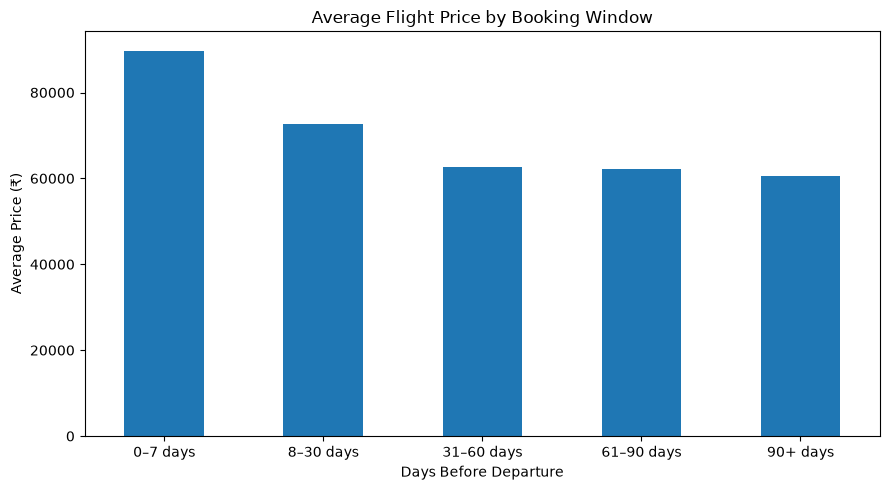

In [219]:
plt.figure(figsize=(9, 5))

booking_prices.plot(kind="bar")

plt.title("Average Flight Price by Booking Window")
plt.xlabel("Days Before Departure")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Flight prices show a clear relationship with how far in advance the booking is made. Flights booked 0–7 days before departure have the highest average price at approximately ₹89,756, while flights booked 90+ days in advance have the lowest average price at approximately ₹60,593.

### Recommendation

Travelers may benefit from booking well in advance rather than waiting until the final week. However, booking time is only one factor, and other variables such as travel class, airline, route, and number of stops can also affect the final price.


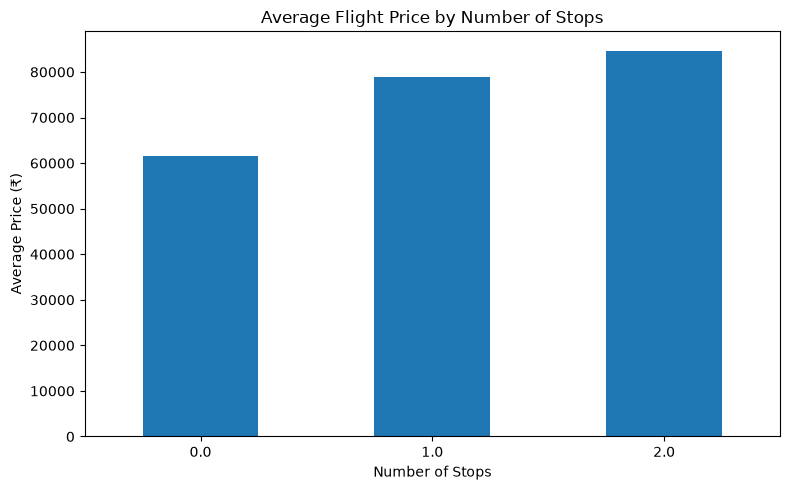

In [220]:
stops_prices = (
    df.groupby("Total_Stops_clean")["Price"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

stops_prices.plot(kind="bar")

plt.title("Average Flight Price by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

The average flight price increases as the number of stops increases in this dataset. Non-stop flights have the lowest average price, while flights with two stops have the highest average price.

This indicates that the number of stops is associated with flight price, although route, distance, airline, and travel class may also contribute to these differences.


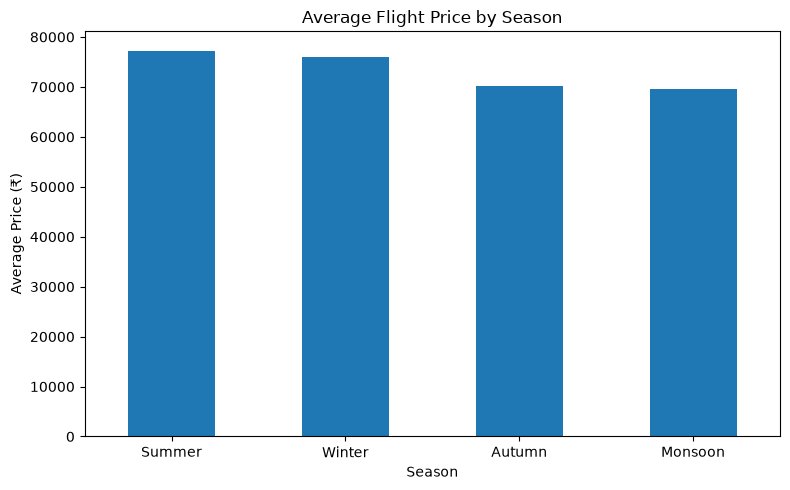

In [221]:
season_prices = (
    df.groupby("Season")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

season_prices.plot(kind="bar")

plt.title("Average Flight Price by Season")
plt.xlabel("Season")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Average flight prices vary across seasons in this dataset. Summer has the highest average price, while Monsoon has the lowest average price.

This suggests that season is associated with differences in flight prices, although other factors may also contribute to the observed differences.

### Recommendation

Travelers with flexible schedules can consider comparing prices across different seasons before booking, as the dataset shows noticeable seasonal variation in average prices.


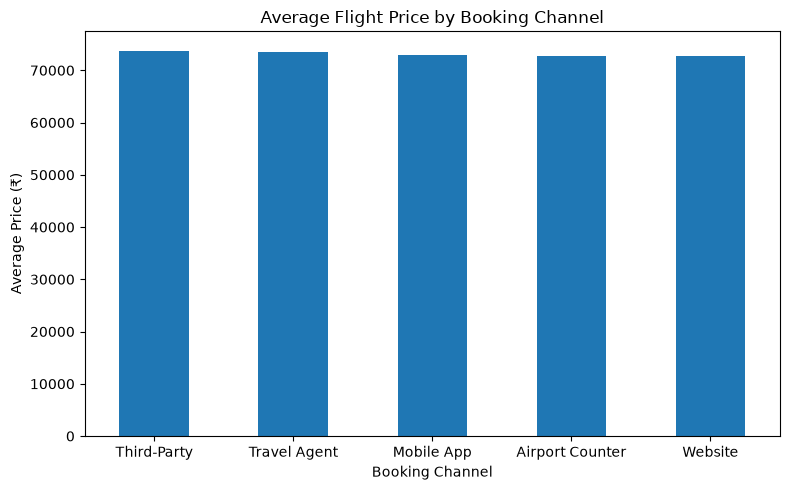

In [222]:
channel_prices = (
    df.groupby("Booking_Channel")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

channel_prices.plot(kind="bar")

plt.title("Average Flight Price by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

The average flight prices across booking channels are relatively similar in this dataset. Third-party platforms and travel agents have slightly higher average prices, while websites and airport counters have slightly lower average prices.

Compared with factors such as travel class and booking time, booking channel appears to have a weaker association with flight price in this dataset.

### Recommendation

Travelers should compare prices across booking channels, but the analysis suggests that the choice of booking channel alone may not have a major effect on the final flight price.


In [223]:
df.to_csv("cleaned_flight_data.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File created: cleaned_flight_data.csv")

Cleaned dataset saved successfully!
File created: cleaned_flight_data.csv


## Key Findings

The analysis shows that several factors are associated with differences in flight prices:

1. **Travel Class:** Travel class shows one of the strongest differences in average price. First and Business class flights are substantially more expensive than Economy flights.
2. **Booking Time:** Flights booked closer to the departure date have higher average prices. The 0–7 day booking window has the highest average price, while bookings made 90+ days in advance have the lowest.
3. **Number of Stops:** Average prices increase as the number of stops increases in this dataset.
4. **Airline:** Average prices vary considerably across airlines, although these differences may also reflect route, travel class, distance, and stop patterns.
5. **Season:** Average prices vary by season, with Summer showing the highest average price and Monsoon the lowest.
6. **Booking Channel:** Booking channel shows relatively small differences in average price compared with the other factors examined.

## Recommendations

* Travelers should consider booking flights well in advance rather than waiting until the final week.
* Travelers with flexible schedules can compare prices across different seasons.
* Travelers should compare flight options across airlines, travel classes, and number of stops rather than considering only the airline.
* Prices should be compared across multiple booking channels, although booking channel appears to have a weaker association with price in this dataset.

## Conclusion

The analysis demonstrates that flight prices are influenced by multiple factors rather than a single variable. Travel class and booking time show particularly clear differences in average prices, while airline, number of stops, and season also show meaningful variation.

These findings can help travelers make more informed decisions when comparing flight options.
